[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jinming99/learn-ml-by-building/blob/main/Lecture%203%20Linear%20Regression/03-Linear-Regression.ipynb)
# Linear Regression: The Universal Pattern Finder

## Today's Mission
**Master linear regression - from simple lines to complex curves - using real-world data**


## Learning Objectives

By the end of this lecture, you will:

1. **See** how the same algorithm solves vastly different non-linear problems
2. **Understand** the linear regression model, its parameters, and the MSE loss function
3. **Master** polynomial features and basis function expansion through hands-on interaction
4. **Apply** these techniques to real problems (weather forecasting, automotive engineering)
5. **Recognize** overfitting and understand when models become too complex
6. **Build** geometric intuition through the "lifting" technique


# Part 1: The Complete Picture First

## Two Different Problems, One Mathematical Solution

Let's start by witnessing something remarkable - the same algorithm solving completely different curved relationships:

### What we'll demonstrate:
- Automotive engineering: curved efficiency relationships
- Weather forecasting: periodic daily patterns
- Both solved with the same linear regression approach
- The key: polynomial feature transformation

In [1]:
# Shared setup: install missing packages once, then import everything used below
import importlib, subprocess, sys, warnings
from subprocess import DEVNULL

required = [
    ('numpy', 'numpy<2'), ('pandas', 'pandas>=1.5,<2.3'),
    ('mlxtend', 'mlxtend>=0.22,<0.24'), ('sklearn', 'scikit-learn>=1.3,<1.5'),
    ('matplotlib', 'matplotlib>=3.7,<3.9'), ('ipywidgets', 'ipywidgets>=7.7,<9'),
    ('climetlab', 'climetlab>=0.20'),
    ('climetlab_mltc_surface_observation_postprocessing',
     'climetlab-mltc-surface-observation-postprocessing>=0.3.0'),
]
for module, package in required:
    try:
        importlib.import_module(module)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package],
                              stdout=DEVNULL)  # Keep installation errors visible

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import climetlab as cml
import climetlab_mltc_surface_observation_postprocessing  # registers the ECMWF dataset
from ipywidgets import interact, FloatSlider, IntSlider, Checkbox
from mlxtend.data import autompg_data
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

def make_polynomial_model(degree):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression()),
    ])

/Users/jinming/Dropbox/learn-ml-by-building/lecture1_overview_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Problem 1: Real automotive data - 392 vehicles from 1970-1982
X_auto, y_auto = autompg_data()

auto_columns = ['cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'model_year', 'origin', 'car_name']
df_auto = pd.DataFrame(X_auto, columns=auto_columns).drop(columns='car_name')
df_auto['mpg'] = y_auto

X_cars = df_auto['displacement'].to_numpy().reshape(-1, 1)
y_mpg = df_auto['mpg'].to_numpy()

print(f"Automotive dataset: {len(df_auto)} real vehicles")
print(f"Engine sizes range from {X_cars.min():.0f} to {X_cars.max():.0f} cubic inches")
print(f"MPG ranges from {y_mpg.min():.1f} to {y_mpg.max():.1f}")

Automotive dataset: 392 real vehicles
Engine sizes range from 68 to 455 cubic inches
MPG ranges from 9.0 to 46.6


In [3]:
# Load actual forecast errors from global weather stations
forecast_error = cml.load_dataset(
    'mltc-surface-observation-postprocessing',
    field='forecast_error'
).to_numpy()

time_of_day = cml.load_dataset(
    'mltc-surface-observation-postprocessing',
    field='time_of_day'
).to_numpy()

print(f"\nWeather dataset: {len(forecast_error):,} observations from 8,000 stations")

# Calculate BASELINE metrics for weather
baseline_rmse = np.sqrt(np.mean(forecast_error**2))
baseline_mae = np.mean(np.abs(forecast_error))
print(f"Weather baseline RMSE: {baseline_rmse:.3f}°C (before any correction)")
print(f"Weather baseline MAE: {baseline_mae:.3f}°C")

# Sample weather data for training
sample_size = 50000
weather_rng = np.random.default_rng(42)
idx = weather_rng.choice(len(forecast_error), sample_size, replace=False)
X_weather = time_of_day[idx].reshape(-1, 1)
y_weather = forecast_error[idx]

By downloading data from this dataset, you agree to the terms and conditions defined at https://github.com/mchantry/climetlab-mltc-sop/blob/main/LICENSE. If you do not agree with such terms, do not download the data. 



Weather dataset: 5,265,488 observations from 8,000 stations
Weather baseline RMSE: 2.254°C (before any correction)
Weather baseline MAE: 1.633°C


### The Magic: Same Algorithm, Different Problems


In [4]:
# THE SAME SOLUTION FOR BOTH REAL DATASETS
poly = PolynomialFeatures(degree=3)

# Fit to automotive data
model_car = LinearRegression().fit(
    poly.fit_transform(X_cars), y_mpg
)

# Fit to weather data  
model_weather = LinearRegression().fit(
    poly.fit_transform(X_weather), y_weather
)

# Calculate performance for automotive
car_predictions = model_car.predict(poly.transform(X_cars))
car_rmse = np.sqrt(metrics.mean_squared_error(y_mpg, car_predictions))
car_r2 = metrics.r2_score(y_mpg, car_predictions)

# Calculate performance for weather (on sample)
weather_predictions = model_weather.predict(poly.transform(X_weather))
weather_baseline_sample = np.sqrt(np.mean(y_weather**2))
weather_corrected_rmse = np.sqrt(metrics.mean_squared_error(y_weather, weather_predictions))
weather_improvement = (weather_baseline_sample - weather_corrected_rmse) / weather_baseline_sample * 100

print(f"\nSame polynomial regression algorithm (degree 3):")
print(f"  Automotive: RMSE = {car_rmse:.2f} MPG, R² = {car_r2:.3f}")
print(f"  Weather: Baseline = {weather_baseline_sample:.3f}°C → Corrected = {weather_corrected_rmse:.3f}°C")


Same polynomial regression algorithm (degree 3):
  Automotive: RMSE = 4.34 MPG, R² = 0.690
  Weather: Baseline = 2.272°C → Corrected = 2.234°C



### Visualizing Real Patterns in Real Data

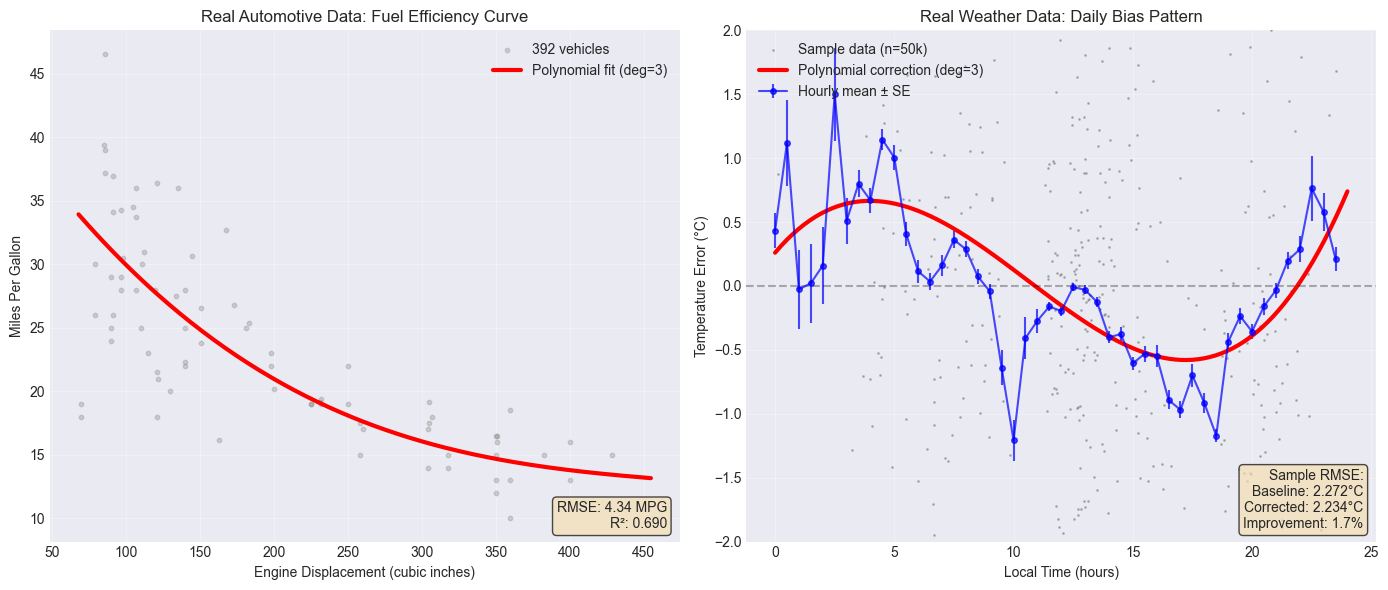

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Real automotive efficiency curve
axes[0].scatter(X_cars[::5], y_mpg[::5], alpha=0.3, s=10, color='gray', label='392 vehicles')
x_car_smooth = np.linspace(X_cars.min(), X_cars.max(), 200).reshape(-1, 1)
axes[0].plot(x_car_smooth, model_car.predict(poly.transform(x_car_smooth)), 
            'r-', linewidth=3, label='Polynomial fit (deg=3)')
axes[0].set_xlabel('Engine Displacement (cubic inches)')
axes[0].set_ylabel('Miles Per Gallon')
axes[0].set_title('Real Automotive Data: Fuel Efficiency Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].text(0.98, 0.02, f'RMSE: {car_rmse:.2f} MPG\nR²: {car_r2:.3f}', 
            transform=axes[0].transAxes, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Real weather forecast errors - show hourly pattern
# Aggregate by hour to see the mean pattern
hours = np.arange(0, 24, 0.5)
mean_errors = []
std_errors = []

for hour in hours:
    mask = (X_weather.flatten() >= hour) & (X_weather.flatten() < hour + 0.5)
    if np.sum(mask) > 0:
        mean_errors.append(np.mean(y_weather[mask]))
        std_errors.append(np.std(y_weather[mask]) / np.sqrt(np.sum(mask)))  # Standard error
    else:
        mean_errors.append(0)
        std_errors.append(0)

mean_errors = np.array(mean_errors)
std_errors = np.array(std_errors)

# Plot the weather data
axes[1].scatter(X_weather[::100], y_weather[::100], alpha=0.5, s=1, color='gray', label='Sample data (n=50k)')
axes[1].errorbar(hours, mean_errors, yerr=std_errors, fmt='o-', 
                 color='blue', alpha=0.7, markersize=4, label='Hourly mean ± SE')

# Overlay polynomial fit
x_weather_smooth = np.linspace(0, 24, 200).reshape(-1, 1)
y_weather_fit = model_weather.predict(poly.transform(x_weather_smooth))
axes[1].plot(x_weather_smooth, y_weather_fit, 'red', linewidth=3, 
            label='Polynomial correction (deg=3)')
axes[1].set_xlabel('Local Time (hours)')
axes[1].set_ylabel('Temperature Error (°C)')
axes[1].set_title('Real Weather Data: Daily Bias Pattern')
axes[1].set_ylim([-2, 2])
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)

# Add performance box for weather
axes[1].text(0.98, 0.02, f'Sample RMSE:\nBaseline: {weather_baseline_sample:.3f}°C\nCorrected: {weather_corrected_rmse:.3f}°C\nImprovement: {weather_improvement:.1f}%', 
            transform=axes[1].transAxes, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()


### Key Insight:

**The SAME polynomial regression (degree 3) solved both problems!**
- Automotive: Captured the inverse relationship between engine size and efficiency"
- Weather: Captured the daily periodic bias in temperature forecasts"

But wait - if these are curves, *why is it called 'LINEAR' regression?*

Let's understand this paradox by building from fundamentals...


# Part 2: Building Understanding from Fundamentals

## Understanding the Basic Model

Now that we've seen the power, let's understand the fundamentals step by step.

### The Linear Model

The simplest form of linear regression:

$$y = wx + b$$

Where:
- $w$ is the **weight** (slope)
- $b$ is the **bias** (intercept)
- $x$ is the input feature
- $y$ is the prediction

### Creating Our Learning Dataset

Let's generate a controlled dataset with hidden complexity - perfect for understanding the concepts:

Dataset characteristics:
  Samples: 200
  True relationship: y = 5 + 2x - 0.3x²
  Noise level: σ = 1.5

Notice the subtle curvature - a linear model will struggle with this!


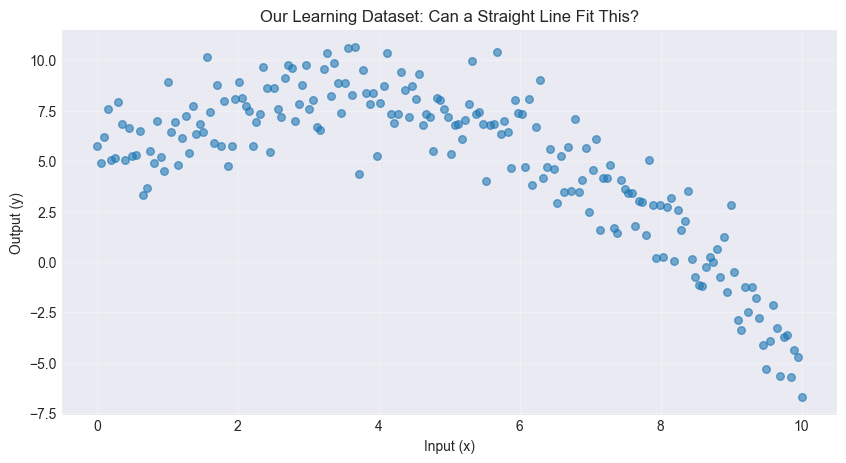

In [6]:
# Generate synthetic data with hidden quadratic relationship
np.random.seed(42)
n_samples = 200

# Create data with a subtle curve (quadratic with noise)
X_learn = np.linspace(0, 10, n_samples)
true_relationship = 5 + 2*X_learn - 0.3*X_learn**2  # Quadratic truth
y_learn = true_relationship + np.random.normal(0, 1.5, n_samples)  # Add noise

# Split for later use
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_learn.reshape(-1, 1), y_learn, test_size=0.3, random_state=42
)

# Initial visualization
plt.figure(figsize=(10, 5))
plt.scatter(X_learn, y_learn, alpha=0.6, s=30)
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.title('Our Learning Dataset: Can a Straight Line Fit This?')
plt.grid(True, alpha=0.3)

print("Dataset characteristics:")
print(f"  Samples: {n_samples}")
print(f"  True relationship: y = 5 + 2x - 0.3x²")
print(f"  Noise level: σ = 1.5")
print("\nNotice the subtle curvature - a linear model will struggle with this!")

## The Mean Squared Error (MSE) Loss Function

### Mathematical Definition

The MSE measures how wrong our predictions are:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

Where:
- $y_i$ is the actual value
- $\hat{y}_i = wx_i + b$ is our prediction
- $n$ is the number of samples

### Computing MSE Manually

Let's implement MSE calculation from scratch to truly understand it:

In [7]:
def calculate_mse(X, y, w, b):
    """Mean squared error for the line y = wx + b."""
    return np.mean((y - (w * X + b)) ** 2)

## Interactive Parameter Exploration

### Tune parameters yourself and watch MSE change in real-time:

In [8]:
def interactive_linear_regression_improved(w=1.0, b=5.0, show_optimal=False):
    """Interactive visualization with 2D MSE contour plot"""

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Ensure local references are defined BEFORE first use (fixes UnboundLocalError)
    X_local = np.asarray(X_learn).ravel()
    Y_local = np.asarray(y_learn).ravel()

    # Calculate MSE for current parameters
    mse_current = calculate_mse(X_local, Y_local, w, b)

    # Fit y ≈ w*x + b (optimal line from data)
    w_optimal, b_optimal = np.polyfit(X_local, Y_local, 1)
    mse_optimal = calculate_mse(X_local, Y_local, w_optimal, b_optimal)

    # Main plot
    axes[0].scatter(X_local, Y_local, alpha=0.4, s=30, label='Data')

    X_line = np.linspace(X_local.min(), X_local.max(), 100)
    y_line = w * X_line + b
    axes[0].plot(X_line, y_line, 'r-', linewidth=2,
                 label=f'Your model: y = {w:.2f}x + {b:.2f}')

    if show_optimal:
        y_optimal_line = w_optimal * X_line + b_optimal
        axes[0].plot(X_line, y_optimal_line, 'g--', linewidth=2, alpha=0.7,
                     label=f'Optimal: y = {w_optimal:.2f}x + {b_optimal:.2f}')

    mse_text = f'Your MSE: {mse_current:.2f}'
    if show_optimal:
        mse_text += f'\nOptimal MSE: {mse_optimal:.2f}'

    axes[0].text(0.05, 0.95, mse_text, transform=axes[0].transAxes,
                 bbox=dict(boxstyle='round',
                           facecolor='lightgreen' if mse_current < mse_optimal + 1 else 'wheat'),
                 verticalalignment='top')

    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title('Adjust Parameters to Minimize MSE')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 2D MSE Contour Plot - EXPANDED RANGE
    w_range = np.linspace(-5, 8, 60)
    b_range = np.linspace(-5, 20, 60)
    W, B = np.meshgrid(w_range, b_range)

    # Calculate MSE for all combinations
    MSE = np.zeros_like(W)
    for i in range(len(b_range)):
        for j in range(len(w_range)):
            MSE[i, j] = calculate_mse(X_local, Y_local, W[i, j], B[i, j])

    # Create contour plot with more levels for better visualization
    levels = np.logspace(np.log10(mse_optimal), np.log10(mse_optimal * 50), 30)
    contour = axes[1].contour(W, B, MSE, levels=levels, cmap='viridis', alpha=0.6)
    axes[1].clabel(contour, inline=True, fontsize=7, fmt='%.0f')

    # Mark current position
    axes[1].scatter([w], [b], color='red', s=200, marker='X',
                    zorder=5, label=f'Current: ({w:.1f}, {b:.1f})')

    # Mark optimal position
    axes[1].scatter([w_optimal], [b_optimal], color='green', s=200,
                    marker='*', zorder=5, label=f'Optimal: ({w_optimal:.1f}, {b_optimal:.1f})')

    # Draw path from current to optimal
    if show_optimal:
        axes[1].arrow(w, b,
                      (w_optimal - w) * 0.8, (b_optimal - b) * 0.8,
                      head_width=0.2, head_length=0.1,
                      fc='yellow', ec='yellow', alpha=0.5, zorder=4)

    axes[1].set_xlabel('Weight (w)')
    axes[1].set_ylabel('Bias (b)')
    axes[1].set_title('MSE Landscape (Complete View)')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([-5, 8])    # match expanded range
    axes[1].set_ylim([-5, 20])   # match expanded range

    plt.tight_layout()
    plt.show()

    if mse_current < mse_optimal + 0.5:
        print("Excellent! You're very close to optimal!")
    else:
        distance = np.sqrt((w - w_optimal)**2 + (b - b_optimal)**2)
        print(f"Distance from optimal: {distance:.2f}")
        print("Try to reach the center of the contour circles!")
        
# Create interactive widget with EXPANDED SLIDER RANGES
print("🎯 Challenge: Navigate to the minimum of the MSE surface!")
print("The contour plot shows the complete landscape - find the valley!\n")
interact(interactive_linear_regression_improved,
         w=FloatSlider(min=-5, max=8, step=0.1, value=1.0, description='Weight (w):'),
         b=FloatSlider(min=-5, max=20, step=0.5, value=5.0, description='Bias (b):'),
         show_optimal=Checkbox(value=False, description='Show Optimal'))

🎯 Challenge: Navigate to the minimum of the MSE surface!
The contour plot shows the complete landscape - find the valley!



interactive(children=(FloatSlider(value=1.0, description='Weight (w):', max=8.0, min=-5.0), FloatSlider(value=…

<function __main__.interactive_linear_regression_improved(w=1.0, b=5.0, show_optimal=False)>

### Learning Through Interaction:
By adjusting parameters, you can see how MSE changes and develop intuition about optimization. Notice how there's a unique minimum in the MSE landscape!


## Revealing the Problem: Linear Models Miss Curves

### Let's see why we need polynomial features:

⚠️ The U-shaped residual pattern reveals our linear model is missing curved structure!
This motivates polynomial features...


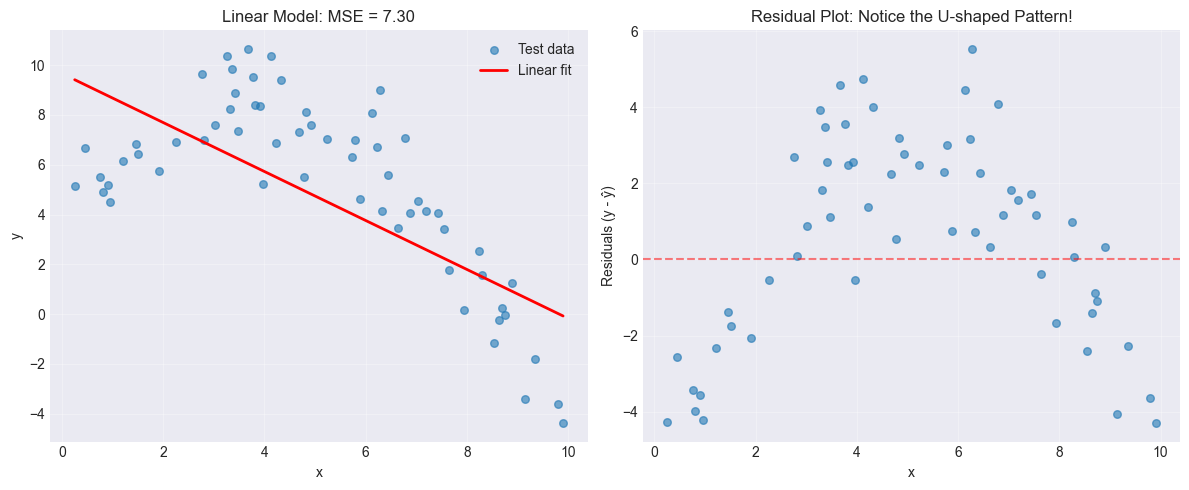

In [9]:
# Re-split from the single source of truth, then fit and inspect residuals
X_full = np.asarray(X_learn).reshape(-1, 1)
y_full = np.asarray(y_learn).ravel()

# Consistent split from the same arrays
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42
)

# Fit
linear_model_simple = LinearRegression()
linear_model_simple.fit(X_train_syn, y_train_syn)
y_linear = linear_model_simple.predict(X_test_syn)

# Visualize with residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Fit plot
axes[0].scatter(X_test_syn.ravel(), y_test_syn, alpha=0.6, s=30, label='Test data')
sort_idx = np.argsort(X_test_syn.ravel())
axes[0].plot(X_test_syn.ravel()[sort_idx], y_linear[sort_idx], 'r-', linewidth=2, label='Linear fit')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title(f'Linear Model: MSE = {metrics.mean_squared_error(y_test_syn, y_linear):.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test_syn - y_linear
axes[1].scatter(X_test_syn.ravel(), residuals, alpha=0.6, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Residuals (y - ŷ)')
axes[1].set_title('Residual Plot: Notice the U-shaped Pattern!')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
print("⚠️ The U-shaped residual pattern reveals our linear model is missing curved structure!")
print("This motivates polynomial features...")

# Part 3: The Polynomial Solution

## Key Concept: Linear in Parameters

Instead of: $y = \theta_0 + \theta_1 x$

We use: $y = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3$

**This is still linear regression** because the model is linear in the parameters $\theta$.

### Interactive Polynomial Degree Exploration

In [10]:
def explore_polynomial_fit(degree=1):
    """Interactive visualization of polynomial regression"""
    
    # Use local train/test split from X_learn/y_learn to avoid conflicts
    # with global variables that may be overwritten by later cells
    X_full_local = np.asarray(X_learn).reshape(-1, 1)
    y_full_local = np.asarray(y_learn).ravel()
    X_train_local, X_test_local, y_train_local, y_test_local = train_test_split(
        X_full_local, y_full_local, test_size=0.3, random_state=42
    )
    
    # Fit polynomial model
    poly_model = make_polynomial_model(degree)
    poly_model.fit(X_train_local, y_train_local)
    
    # Predictions
    y_poly = poly_model.predict(X_test_local)
    
    # Calculate metrics
    train_score = poly_model.score(X_train_local, y_train_local)
    test_score = poly_model.score(X_test_local, y_test_local)
    mse_poly = metrics.mean_squared_error(y_test_local, y_poly)
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Fit plot
    axes[0].scatter(X_test_local, y_test_local, alpha=0.4, s=30, label='Test data')
    X_smooth = np.linspace(0, 10, 200).reshape(-1, 1)
    y_smooth = poly_model.predict(X_smooth)
    axes[0].plot(X_smooth, y_smooth, 'g-', linewidth=2, label=f'Polynomial (degree={degree})')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title(f'Polynomial Fit: MSE = {mse_poly:.2f}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([-5, 15])
    
    # Residuals
    residuals_poly = y_test_local - y_poly
    axes[1].scatter(X_test_local, residuals_poly, alpha=0.6, s=30)
    axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residual Pattern')
    axes[1].grid(True, alpha=0.3)
    
    # Color code background
    if degree == 2:
        fig.patch.set_facecolor('#E8F5E9')  # Green - optimal
        status = "Perfect! Matches the true quadratic relationship"
    elif degree == 1:
        fig.patch.set_facecolor('#FFF3E0')  # Amber - underfitting
        status = "Underfitting - missing curved structure"
    elif degree > 5:
        fig.patch.set_facecolor('#FFEBEE')  # Red - overfitting risk
        status = "Overfitting risk - too complex"
    else:
        fig.patch.set_facecolor('white')
        status = "Good fit"
    
    plt.suptitle(f'Status: {status} | Train R²: {train_score:.3f} | Test R²: {test_score:.3f}')
    plt.tight_layout()
    plt.show()
    
    print(f"Polynomial equation has {degree + 1} parameters")
    if degree == 2:
        print("✨ Degree 2 matches our true relationship: y = 5 + 2x - 0.3x²")

# Interactive widget
print("🔬 Experiment with polynomial degree:")
print("Watch how residual patterns change!\n")
interact(explore_polynomial_fit,
         degree=IntSlider(min=1, max=10, step=1, value=1, description='Degree:'))

🔬 Experiment with polynomial degree:
Watch how residual patterns change!



interactive(children=(IntSlider(value=1, description='Degree:', max=10, min=1), Output()), _dom_classes=('widg…

<function __main__.explore_polynomial_fit(degree=1)>

# Part 4: The Lifting Technique - Geometric Intuition

## Revolutionary Visualization: From Curves to Planes

### The fundamental insight:
- In original space: non-linear curved relationships
- After transformation: linear relationships in higher dimensions
- We're "lifting" data into a space where linear regression works

In [11]:
def visualize_lifting_technique(selected_x=4.0):
    """Show the same model point before and after phi(x) = [x, x²]."""
    X_vis = np.asarray(X_learn).ravel()
    y_vis = np.asarray(y_learn).ravel()

    model = make_polynomial_model(2).fit(X_vis.reshape(-1, 1), y_vis)
    linear = model.named_steps['linear']
    b0 = float(linear.intercept_)
    b1, b2 = linear.coef_.ravel()

    x_line = np.linspace(X_vis.min(), X_vis.max(), 250)
    y_line = model.predict(x_line.reshape(-1, 1))
    selected_y = float(model.predict([[selected_x]])[0])

    # Five matching observations make the point-to-point correspondence visible.
    targets = np.quantile(X_vis, [0.08, 0.28, 0.50, 0.72, 0.92])
    sample_idx = [np.abs(X_vis - target).argmin() for target in targets]
    sample_x, sample_y = X_vis[sample_idx], y_vis[sample_idx]
    sample_pred = model.predict(sample_x.reshape(-1, 1))
    colors = ['#5E60CE', '#00A6A6', '#F59E0B', '#E05252', '#2F6BFF']

    fig = plt.figure(figsize=(15, 5.5))
    grid = fig.add_gridspec(1, 3, width_ratios=[1, 0.28, 1.25])
    ax_original = fig.add_subplot(grid[0])
    ax_map = fig.add_subplot(grid[1])
    ax_lifted = fig.add_subplot(grid[2], projection='3d')

    # 1. Original space: the fitted relationship is curved.
    ax_original.scatter(X_vis, y_vis, color='lightgray', alpha=0.35, s=18,
                        label='Observations')
    ax_original.plot(x_line, y_line, color='#2F6BFF', linewidth=3,
                     label='Quadratic fit')
    ax_original.scatter(sample_x, sample_y, c=colors, s=70,
                        edgecolor='white', linewidth=1.4, zorder=4)
    ax_original.scatter([selected_x], [selected_y], s=180, facecolor='none',
                        edgecolor='#E05252', linewidth=3, zorder=5)
    ax_original.axvline(selected_x, color='#E05252', linestyle=':', alpha=0.55)
    ax_original.set_xlabel('Input x')
    ax_original.set_ylabel('Target y')
    ax_original.set_title('1. Curved in the Original Space')
    ax_original.legend(loc='lower right')
    ax_original.grid(True, alpha=0.2)

    # Explicitly name the feature map between the two views.
    ax_map.axis('off')
    ax_map.text(0.5, 0.66, r'$\phi(x)$', ha='center', va='center', fontsize=16)
    ax_map.text(0.5, 0.56, r'$[x,\ x^2]$', ha='center', va='center', fontsize=14)
    ax_map.annotate('', xy=(0.95, 0.43), xytext=(0.05, 0.43),
                    arrowprops=dict(arrowstyle='->', linewidth=3, color='#E05252'))
    ax_map.text(0.5, 0.34, 'same colors =\nsame observations',
                ha='center', va='center', color='dimgray', fontsize=10)

    # 2. Lifted space: the prediction rule is a plane.
    x_mesh = np.linspace(X_vis.min(), X_vis.max(), 24)
    x2_mesh = np.linspace(0, X_vis.max()**2, 24)
    X_mesh, X2_mesh = np.meshgrid(x_mesh, x2_mesh)
    Y_plane = b0 + b1 * X_mesh + b2 * X2_mesh
    ax_lifted.plot_surface(X_mesh, X2_mesh, Y_plane, color='#86D4BE',
                           alpha=0.32, edgecolor='#4FAF91', linewidth=0.25,
                           rstride=3, cstride=3, antialiased=True)
    ax_lifted.scatter(X_vis, X_vis**2, y_vis, color='slategray', alpha=0.22,
                      s=16, edgecolor='none', depthshade=False,
                      label='Lifted observations')
    ax_lifted.plot(x_line, x_line**2, y_line, color='#2F6BFF', linewidth=4,
                   label='Valid lifted inputs')
    ax_lifted.scatter(sample_x, sample_x**2, sample_y, c=colors, s=65,
                      edgecolor='white', linewidth=1.2, depthshade=False)

    # Residual segments show how noisy observations sit above or below the plane.
    for x, y, y_hat in zip(sample_x, sample_y, sample_pred):
        ax_lifted.plot([x, x], [x**2, x**2], [y_hat, y],
                       color='gray', linestyle=':', linewidth=1.2)

    ax_lifted.scatter([selected_x], [selected_x**2], [selected_y], s=190,
                      facecolor='none', edgecolor='#E05252', linewidth=3,
                      depthshade=False)
    ax_lifted.set_xlabel('x')
    ax_lifted.set_ylabel('x²')
    ax_lifted.set_zlabel('Prediction y')
    ax_lifted.set_title('2. Linear on a Plane After Lifting')
    ax_lifted.set_proj_type('ortho')
    ax_lifted.set_box_aspect((1.15, 1.15, 0.8))
    ax_lifted.view_init(elev=34, azim=-125)
    ax_lifted.legend(loc='upper left')

    fig.suptitle(f'The Same Model Point Before and After Lifting  |  x = {selected_x:.2f}',
                 fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


_ = interact(
    visualize_lifting_technique,
    selected_x=FloatSlider(
        min=float(np.min(X_learn)), max=float(np.max(X_learn)),
        step=0.1, value=4.0, description='Selected x:',
        continuous_update=False,
    ),
)

interactive(children=(FloatSlider(value=4.0, continuous_update=False, description='Selected x:', max=10.0), Ou…

### Key Insight

By adding $x^2$ as a new dimension, curves become planes.  

This is why polynomial regression is still “linear” regression.

#### Equations
- Original space (quadratic model):
$$
y = \theta_0 + \theta_1 x + \theta_2 x^2
$$

- Lifted space (linear in features x₁, x₂):
$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2
$$

(where $x_1 = x$ and $x_2 = x^2$)

# Part 5: Real-World Application - Weather Forecasting

## Applying Polynomial Regression to Weather Data

Now let's apply what we've learned to the weather forecasting problem we loaded at the beginning. We'll use the ECMWF data to show how polynomial regression is used operationally to correct systematic biases in numerical weather prediction models.

### Using Our Previously Loaded Data

In [12]:
# We already loaded the weather data in Part 1, let's use it now
print(f"Using weather dataset loaded earlier: {len(forecast_error):,} observations")
print(f"Sample size for training: {len(X_weather):,} observations")
print(f"Baseline RMSE: {baseline_rmse:.3f}°C")

# Split the sampled weather data for proper evaluation
X_train_weather, X_test_weather, y_train_weather, y_test_weather = train_test_split(
    X_weather, y_weather, test_size=0.2, random_state=42
)

print(f"\nTraining on {len(X_train_weather):,} observations")
print(f"Testing on {len(X_test_weather):,} observations")

Using weather dataset loaded earlier: 5,265,488 observations
Sample size for training: 50,000 observations
Baseline RMSE: 2.254°C

Training on 40,000 observations
Testing on 10,000 observations


### Comparing Different Polynomial Degrees

Just as we experimented with different degrees on our synthetic data, let's systematically test which polynomial degree works best for the weather bias correction problem. This mirrors the actual research process that led to ECMWF's operational choice of cubic polynomials.

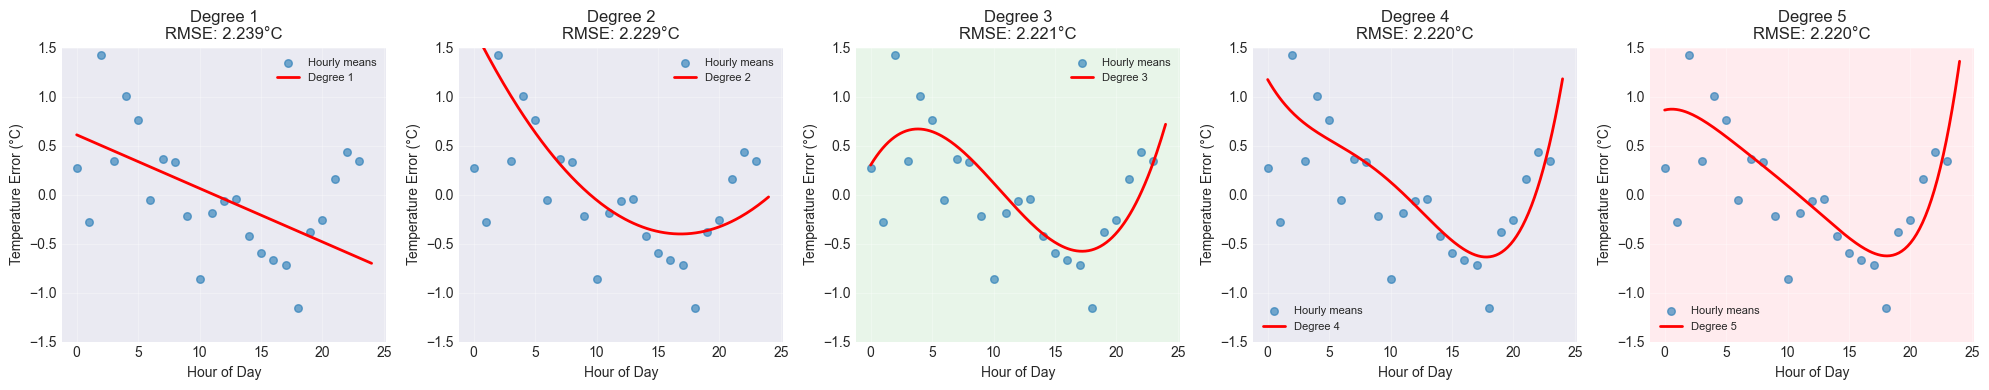


Polynomial Degree Comparison for Weather Data:
Degree | Test RMSE | Improvement over baseline
-------|-----------|-------------------------
   1   | 2.2392°C | +0.93%
   2   | 2.2287°C | +1.39%
   3   | 2.2214°C | +1.71%
   4   | 2.2202°C | +1.77%
   5   | 2.2200°C | +1.77%

Optimal degree: 5


In [13]:
# Test different polynomial degrees on weather data
degrees_to_test = [1, 2, 3, 4, 5]
weather_results = []

fig, axes = plt.subplots(1, len(degrees_to_test), figsize=(20, 4))

for idx, degree in enumerate(degrees_to_test):
    # Create and train model
    poly_weather_model = make_polynomial_model(degree)
    poly_weather_model.fit(X_train_weather, y_train_weather)
    
    # Evaluate
    predictions = poly_weather_model.predict(X_test_weather)
    test_rmse = np.sqrt(metrics.mean_squared_error(y_test_weather, predictions))
    weather_results.append((degree, test_rmse))
    
    # Visualize
    ax = axes[idx]
    
    # Show hourly means for reference
    hours = np.arange(0, 24, 1)
    hourly_means = []
    for hour in hours:
        mask = (X_test_weather.flatten() >= hour) & (X_test_weather.flatten() < hour + 1)
        if np.sum(mask) > 0:
            hourly_means.append(np.mean(y_test_weather[mask]))
        else:
            hourly_means.append(0)
    
    ax.scatter(hours, hourly_means, alpha=0.6, s=30, label='Hourly means')
    
    # Plot polynomial fit
    x_smooth = np.linspace(0, 24, 200).reshape(-1, 1)
    y_smooth = poly_weather_model.predict(x_smooth)
    ax.plot(x_smooth, y_smooth, 'r-', linewidth=2, label=f'Degree {degree}')
    
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Temperature Error (°C)')
    ax.set_title(f'Degree {degree}\nRMSE: {test_rmse:.3f}°C')
    ax.set_ylim([-1.5, 1.5])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Color code by performance
    if degree == 3:
        ax.set_facecolor('#E8F5E9')  # Green for optimal
    elif degree > 4:
        ax.set_facecolor('#FFEBEE')  # Red for overfitting risk

plt.tight_layout()
plt.show()

# Display results table
print("\nPolynomial Degree Comparison for Weather Data:")
print("Degree | Test RMSE | Improvement over baseline")
print("-------|-----------|-------------------------")
baseline_sample_rmse = np.sqrt(np.mean(y_test_weather**2))
for degree, rmse in weather_results:
    improvement = (baseline_sample_rmse - rmse) / baseline_sample_rmse * 100
    print(f"   {degree}   | {rmse:.4f}°C | {improvement:+.2f}%")

optimal_degree = min(weather_results, key=lambda x: x[1])[0]
print(f"\nOptimal degree: {optimal_degree}")

### A Flexible Baseline: ECMWF's Cubic Implementation

The panels above show that polynomial features provide a flexible baseline for daily temperature bias. ECMWF chose a degree-3 (cubic) polynomial after extensive validation: it captures the asymmetric pattern without excessive complexity. Later, we will keep the same linear-regression algorithm but replace the polynomial basis with periodic features that encode the clock directly.


ECMWF Operational Model:
  Equation: y = 0.3021 + 0.20729t + -0.0330164t² + 0.001045936t³
  Test RMSE: 2.2214°C
  Improvement: 1.71%


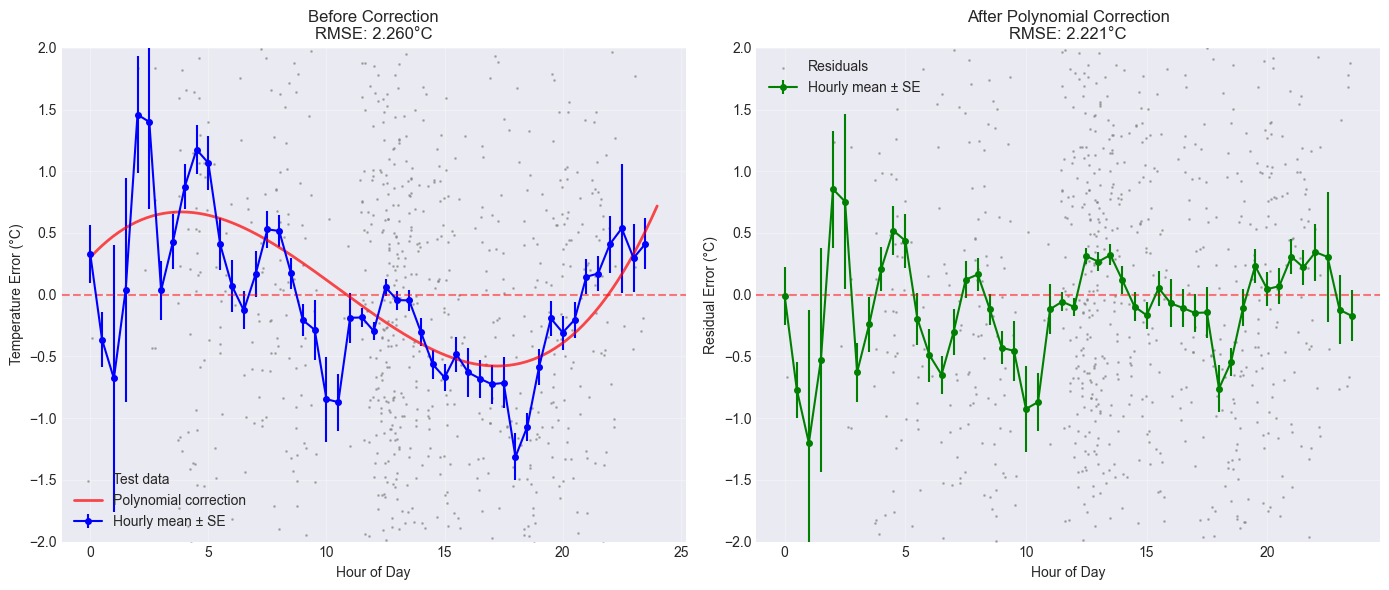


Pattern Analysis:
Before correction - mean bias by time of day ranges from -1.314 to 1.459°C
After correction - residual bias ranges from -1.201 to 0.855°C
Variance reduction: 3.1%


In [14]:
# ECMWF's cubic baseline, using the same helper as the earlier examples
ecmwf_model = make_polynomial_model(3)
ecmwf_model.fit(X_train_weather, y_train_weather.ravel())
ecmwf_predictions = ecmwf_model.predict(X_test_weather)
ecmwf_rmse = np.sqrt(metrics.mean_squared_error(y_test_weather, ecmwf_predictions))
c0 = float(ecmwf_model.named_steps['linear'].intercept_)
c1, c2, c3 = ecmwf_model.named_steps['linear'].coef_.ravel()

print("ECMWF Operational Model:")
print(f"  Equation: y = {c0:.4f} + {c1:.5f}t + {c2:.7f}t² + {c3:.9f}t³")
print(f"  Test RMSE: {ecmwf_rmse:.4f}°C")
print(f"  Improvement: {(baseline_sample_rmse - ecmwf_rmse)/baseline_sample_rmse*100:.2f}%")

# Better visualization that actually shows the patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before correction - show actual data distribution
axes[0].scatter(X_test_weather.flatten()[::10], y_test_weather[::10], 
                alpha=0.5, s=1, color='gray', label='Test data')

# Calculate and plot hourly means to show the pattern
hours = np.arange(0, 24, 0.5)
mean_before = []
std_before = []
for hour in hours:
    mask = (X_test_weather.flatten() >= hour) & (X_test_weather.flatten() < hour + 0.5)
    if mask.sum() > 0:
        mean_before.append(np.mean(y_test_weather[mask]))
        std_before.append(np.std(y_test_weather[mask]) / np.sqrt(mask.sum()))
    else:
        mean_before.append(np.nan)
        std_before.append(np.nan)

axes[0].errorbar(hours, mean_before, yerr=np.array(std_before), 
                 fmt='o-', color='blue', markersize=4, label='Hourly mean ± SE')
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Temperature Error (°C)')
axes[0].set_title(f'Before Correction\nRMSE: {baseline_sample_rmse:.3f}°C')
axes[0].set_ylim([-2, 2])
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# After correction - show residuals
residuals = y_test_weather.flatten() - ecmwf_predictions.flatten()
axes[1].scatter(X_test_weather.flatten()[::10], residuals[::10], 
                alpha=0.5, s=1, color='gray', label='Residuals')

# Calculate hourly means of residuals
mean_after = []
std_after = []
for hour in hours:
    mask = (X_test_weather.flatten() >= hour) & (X_test_weather.flatten() < hour + 0.5)
    if mask.sum() > 0:
        mean_after.append(np.mean(residuals[mask]))
        std_after.append(np.std(residuals[mask]) / np.sqrt(mask.sum()))
    else:
        mean_after.append(np.nan)
        std_after.append(np.nan)

axes[1].errorbar(hours, mean_after, yerr=np.array(std_after), 
                 fmt='o-', color='green', markersize=4, label='Hourly mean ± SE')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Residual Error (°C)')
axes[1].set_title(f'After Polynomial Correction\nRMSE: {ecmwf_rmse:.3f}°C')
axes[1].set_ylim([-2, 2])
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Add the polynomial correction curve to the first plot to show what we're correcting
x_smooth = np.linspace(0, 24, 200)
y_correction = ecmwf_model.predict(x_smooth.reshape(-1, 1))
axes[0].plot(x_smooth, y_correction, 'r-', linewidth=2, alpha=0.7, label='Polynomial correction')
axes[0].legend()

plt.tight_layout()
plt.show()

# Print diagnostic information
print(f"\nPattern Analysis:")
print(f"Before correction - mean bias by time of day ranges from {np.nanmin(mean_before):.3f} to {np.nanmax(mean_before):.3f}°C")
print(f"After correction - residual bias ranges from {np.nanmin(mean_after):.3f} to {np.nanmax(mean_after):.3f}°C")
print(f"Variance reduction: {(np.var(y_test_weather) - np.var(residuals))/np.var(y_test_weather)*100:.1f}%")

# Part 6: When Models Go Wrong - Overfitting

## Interactive Overfitting Demonstration

In [15]:
# ===== Source data =====
# Use the arrays you built earlier for this lecture:
# If your arrays are named differently, replace X_learn/y_learn below.
X_full = np.asarray(X_learn).reshape(-1, 1)
y_full = np.asarray(y_learn).ravel()

# Consistent train/test split from the SAME arrays (prevents length mismatches)
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42
)

def demonstrate_overfitting(n_points=30, degree=2):
    """Interactive demonstration of overfitting with a consistent split and shapes."""
    # Clamp n_points to available training size
    n_points = int(np.clip(n_points, 1, len(X_train_syn)))

    # Limited training subset
    X_small = X_train_syn[:n_points]
    y_small = y_train_syn[:n_points]

    # Fit polynomial model
    poly_model = make_polynomial_model(degree)
    poly_model.fit(X_small, y_small)

    # Metrics
    train_score = poly_model.score(X_small, y_small)
    test_score = poly_model.score(X_test_syn, y_test_syn)
    n_features = degree + 1  # for 1D x, number of polynomial terms is degree+1

    # Figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Fit visualization
    axes[0].scatter(X_small.ravel(), y_small, s=80, alpha=0.7, zorder=3,
                    label=f'Training ({n_points} points)', color='blue')
    axes[0].scatter(X_test_syn.ravel(), y_test_syn, s=10, alpha=0.2, color='gray', label='Test data')

    # Plot range based on data
    x_min, x_max = X_full.min(), X_full.max()
    pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
    X_plot = np.linspace(x_min - pad, x_max + pad, 300).reshape(-1, 1)
    y_pred = poly_model.predict(X_plot)

    axes[0].plot(X_plot.ravel(), y_pred, 'r-', linewidth=2, label=f'Degree {degree}')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('y')
    axes[0].set_title(f'Polynomial Fit (Degree {degree})')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)

    # Performance bar chart
    metrics_data = ['Train R²', 'Test R²', 'Overfit Gap']
    values = [train_score, max(0, test_score), max(0, train_score - test_score)]
    colors_bar = ['blue', 'orange', 'red']

    bars = axes[1].bar(metrics_data, values, color=colors_bar)
    axes[1].set_ylim([0, 1.2])
    axes[1].set_title('Model Performance')
    axes[1].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good performance')
    axes[1].legend()

    for bar, value in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{value:.3f}', ha='center', va='bottom')

    # Status indicator
    data_per_param = n_points / n_features
    if test_score < 0.3 or (train_score - test_score) > 0.3:
        status = "⚠️ Severe overfitting!"
        fig.patch.set_facecolor('#FFEBEE')
    elif (train_score - test_score) > 0.15:
        status = "⚡ Overfitting detected"
        fig.patch.set_facecolor('#FFF3E0')
    else:
        status = "✅ Good balance"
        fig.patch.set_facecolor('#E8F5E9')

    plt.suptitle(f'{status} | Parameters: {n_features} | Data/Parameter Ratio: {data_per_param:.1f}')
    plt.tight_layout()
    plt.show()

    if degree > n_points // 5:
        print(f"⚠️ Warning: With {n_points} points and degree {degree}, you have {n_features} parameters.")
        print("Rule of thumb: You need at least 5-10 data points per parameter!")

# Interactive widget
print("🔬 Experiment with overfitting:")
print("Try high degree with few points to see severe overfitting!\n")
interact(
    demonstrate_overfitting,
    degree=IntSlider(min=1, max=15, step=1, value=2, description='Degree:'),
    n_points=IntSlider(min=10, max=min(100, len(X_train_syn)), step=10, value=30, description='Training Points:')
)

🔬 Experiment with overfitting:
Try high degree with few points to see severe overfitting!



interactive(children=(IntSlider(value=30, description='Training Points:', min=10, step=10), IntSlider(value=2,…

<function __main__.demonstrate_overfitting(n_points=30, degree=2)>

# Part 7: Feature Engineering - Beyond Simple Polynomials

## Domain Knowledge Beats Brute Force

Polynomial features are flexible, but domain-specific transformations can express useful structure more directly. Here, three interpretable automotive features outperform three polynomial features on the same train/test split.

### Physics-Informed Features for Automotive Data

Instead of blindly adding polynomial terms, let's use automotive physics:

In [16]:
# Reuse the correctly labeled Auto MPG data loaded at the start
df_auto['power_weight_ratio'] = df_auto['horsepower'] / df_auto['weight']
df_auto['inverse_displacement'] = 1 / df_auto['displacement']
physics_features = ['weight', 'power_weight_ratio', 'inverse_displacement']

train_idx, test_idx = train_test_split(
    np.arange(len(df_auto)), test_size=0.2, random_state=42
)
model_poly = make_polynomial_model(3)
model_physics = Pipeline([
    ('scale', StandardScaler()),
    ('linear', LinearRegression()),
])

model_poly.fit(df_auto[['displacement']].iloc[train_idx], y_auto[train_idx])
model_physics.fit(df_auto[physics_features].iloc[train_idx], y_auto[train_idx])
rmse_poly = np.sqrt(metrics.mean_squared_error(
    y_auto[test_idx], model_poly.predict(df_auto[['displacement']].iloc[test_idx])
))
rmse_physics = np.sqrt(metrics.mean_squared_error(
    y_auto[test_idx], model_physics.predict(df_auto[physics_features].iloc[test_idx])
))

print("\nModel Comparison:")
print(f"Polynomial (degree 3): 3 features, RMSE = {rmse_poly:.2f} MPG")
print(f"Domain-informed: {len(physics_features)} features, RMSE = {rmse_physics:.2f} MPG")


Model Comparison:
Polynomial (degree 3): 3 features, RMSE = 4.56 MPG
Domain-informed: 3 features, RMSE = 4.28 MPG



### Visualizing Feature-Target Correlations

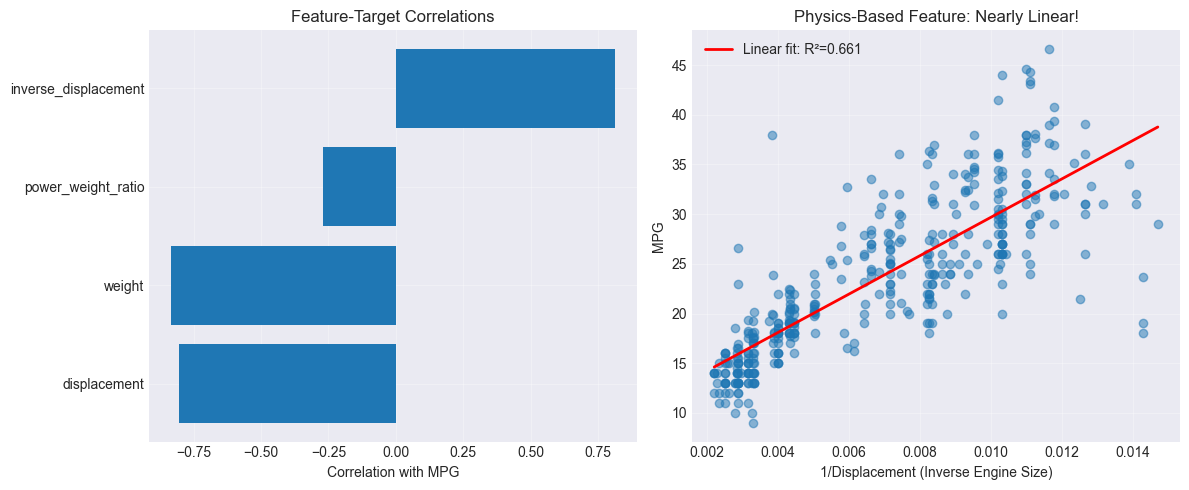

In [17]:
# Compare simple correlations with MPG
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Feature correlations with MPG
correlations = df_auto[['displacement', 'weight', 'power_weight_ratio', 'inverse_displacement', 'mpg']].corr()['mpg'][:-1]
axes[0].barh(range(len(correlations)), correlations.values)
axes[0].set_yticks(range(len(correlations)))
axes[0].set_yticklabels(correlations.index)
axes[0].set_xlabel('Correlation with MPG')
axes[0].set_title('Feature-Target Correlations')
axes[0].grid(True, alpha=0.3)

# Scatter plot of best engineered feature
axes[1].scatter(df_auto['inverse_displacement'], df_auto['mpg'], alpha=0.5)
axes[1].set_xlabel('1/Displacement (Inverse Engine Size)')
axes[1].set_ylabel('MPG')
axes[1].set_title('Physics-Based Feature: Nearly Linear!')
axes[1].grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(df_auto['inverse_displacement'], df_auto['mpg'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_auto['inverse_displacement'].min(), df_auto['inverse_displacement'].max(), 100)
axes[1].plot(x_line, p(x_line), "r-", linewidth=2, label=f'Linear fit: R²={metrics.r2_score(df_auto["mpg"], p(df_auto["inverse_displacement"])):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## Capturing Discontinuities: The Frozen Soil Example

Weather models need to handle the phase transition at 0°C, where water freezes and heat transfer changes dramatically:

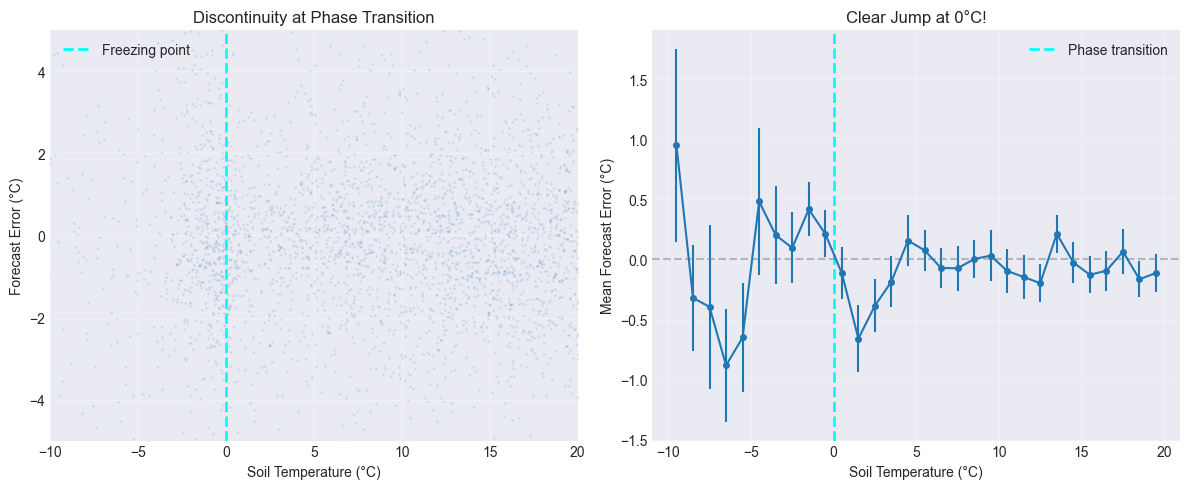

Error difference across freezing point: 0.615°C
A simple binary feature captures this complex physics!


In [18]:
# Load soil temperature data (if not already loaded)
if 'soil_temperature' not in locals():
    soil_temperature = cml.load_dataset(
        'mltc-surface-observation-postprocessing',
        field='soil_temperature'
    ).to_numpy()

# Sample for visualization
sample_idx = np.random.default_rng(42).choice(len(forecast_error), 5000, replace=False)
soil_temp_sample = soil_temperature[sample_idx]
error_sample = forecast_error[sample_idx]

# Create frozen indicator
soil_frozen = (soil_temp_sample < 0).astype(float)

# Visualize the discontinuity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw relationship
axes[0].scatter(soil_temp_sample, error_sample, alpha=0.1, s=1)
axes[0].axvline(0, color='cyan', linestyle='--', linewidth=2, label='Freezing point')
axes[0].set_xlabel('Soil Temperature (°C)')
axes[0].set_ylabel('Forecast Error (°C)')
axes[0].set_title('Discontinuity at Phase Transition')
axes[0].set_xlim([-10, 20])
axes[0].set_ylim([-5, 5])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Binned means to show the jump
bins = np.linspace(-10, 20, 31)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_means = []
bin_stds = []

for i in range(len(bins)-1):
    mask = (soil_temp_sample >= bins[i]) & (soil_temp_sample < bins[i+1])
    if mask.sum() > 0:
        bin_means.append(np.mean(error_sample[mask]))
        bin_stds.append(np.std(error_sample[mask]) / np.sqrt(mask.sum()))
    else:
        bin_means.append(np.nan)
        bin_stds.append(np.nan)

axes[1].errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', markersize=4)
axes[1].axvline(0, color='cyan', linestyle='--', linewidth=2, label='Phase transition')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Soil Temperature (°C)')
axes[1].set_ylabel('Mean Forecast Error (°C)')
axes[1].set_title('Clear Jump at 0°C!')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Error difference across freezing point: {np.mean(error_sample[soil_frozen==1]) - np.mean(error_sample[soil_frozen==0]):.3f}°C")
print("A simple binary feature captures this complex physics!")


## From a Flexible Baseline to a Better Basis

The cubic polynomial was a useful baseline, but time of day is cyclic: hour 24 connects directly back to hour 0. We can keep the same `LinearRegression` algorithm and supply sine/cosine features that encode this structure explicitly. The model remains linear in its parameters, while the basis functions become better matched to the problem.

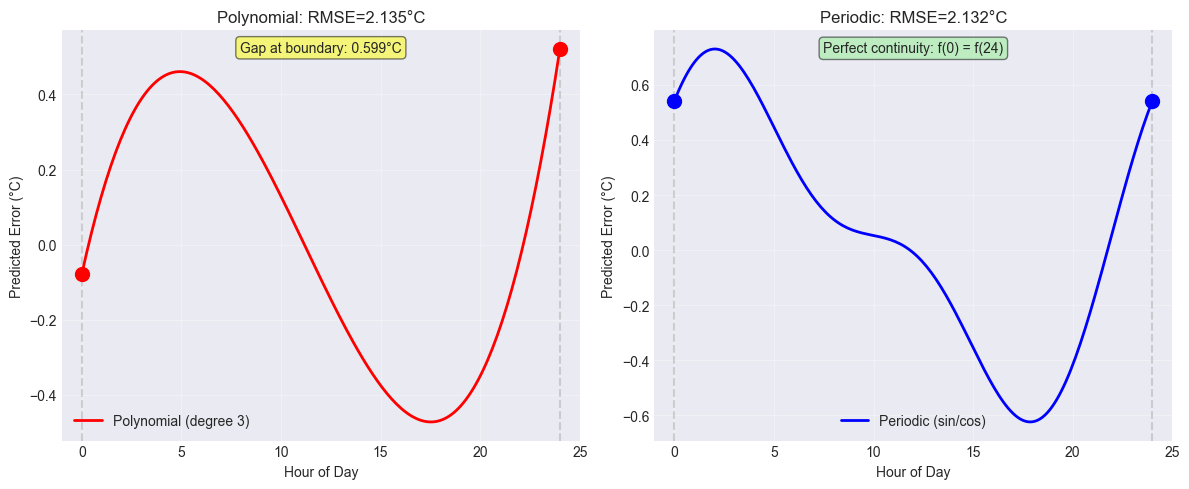

In [19]:
# Compare polynomial vs periodic features for time of day
time_sample = time_of_day[sample_idx]

# Create feature sets
# Polynomial features
time_poly = np.column_stack([time_sample, time_sample**2, time_sample**3])

# Periodic features (Fourier basis)
time_periodic = np.column_stack([
    np.sin(2*np.pi*time_sample/24),  # Daily cycle
    np.cos(2*np.pi*time_sample/24),
    np.sin(4*np.pi*time_sample/24),  # Semi-daily cycle  
    np.cos(4*np.pi*time_sample/24)
])

# Split and train
X_train_poly, X_test_poly, y_train_time, y_test_time = train_test_split(time_poly, error_sample, test_size=0.2, random_state=42)
X_train_periodic, X_test_periodic, _, _ = train_test_split(time_periodic, error_sample, test_size=0.2, random_state=42)

model_poly_time = LinearRegression().fit(X_train_poly, y_train_time)
model_periodic = LinearRegression().fit(X_train_periodic, y_train_time)

# Evaluate
rmse_poly_time = np.sqrt(metrics.mean_squared_error(y_test_time, model_poly_time.predict(X_test_poly)))
rmse_periodic = np.sqrt(metrics.mean_squared_error(y_test_time, model_periodic.predict(X_test_periodic)))

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Generate smooth predictions
t_smooth = np.linspace(0, 24, 200)
t_poly_smooth = np.column_stack([t_smooth, t_smooth**2, t_smooth**3])
t_periodic_smooth = np.column_stack([
    np.sin(2*np.pi*t_smooth/24),
    np.cos(2*np.pi*t_smooth/24),
    np.sin(4*np.pi*t_smooth/24),
    np.cos(4*np.pi*t_smooth/24)
])

pred_poly = model_poly_time.predict(t_poly_smooth)
pred_periodic = model_periodic.predict(t_periodic_smooth)

# Polynomial approach
axes[0].plot(t_smooth, pred_poly, 'r-', linewidth=2, label='Polynomial (degree 3)')
axes[0].scatter([0, 24], [pred_poly[0], pred_poly[-1]], s=100, c='red', zorder=5)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Predicted Error (°C)')
axes[0].set_title(f'Polynomial: RMSE={rmse_poly_time:.3f}°C')
axes[0].set_xlim([-1, 25])
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(24, color='gray', linestyle='--', alpha=0.3)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Fix the scalar extraction
axes[0].text(12, axes[0].get_ylim()[1]*0.9, 
            f'Gap at boundary: {abs(float(pred_poly[0]) - float(pred_poly[-1])):.3f}°C',
            ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# Periodic approach
axes[1].plot(t_smooth, pred_periodic, 'b-', linewidth=2, label='Periodic (sin/cos)')
axes[1].scatter([0, 24], [pred_periodic[0], pred_periodic[-1]], s=100, c='blue', zorder=5)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Predicted Error (°C)')
axes[1].set_title(f'Periodic: RMSE={rmse_periodic:.3f}°C')
axes[1].set_xlim([-1, 25])
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(24, color='gray', linestyle='--', alpha=0.3)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].text(12, axes[1].get_ylim()[1]*0.9, 
            f'Perfect continuity: f(0) = f(24)',
            ha='center', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()



# Wrap-Up & Key Takeaways

Linear regression is linear in its parameters, not necessarily in its raw inputs: polynomial terms can reveal curves, sine and cosine can represent cycles, and threshold indicators can capture discontinuities while the underlying fitting algorithm remains unchanged. Mean squared error provides the objective, residuals reveal structure the model has missed, and evaluation on unseen data guards against overfitting; in practice, start simple, add complexity only when the evidence supports it, and prefer a few features grounded in the problem's geometry or physics over a larger collection of arbitrary ones.

# Acknowledgments

**ECMWF Weather Dataset**: European Centre for Medium-Range Weather Forecasts (ECMWF), accessed via ClimeLab `climetlab-mltc-surface-observation-postprocessing` (Apache 2.0 License). Contains 5.2M observations from 8,000+ global weather stations.

**Auto MPG Dataset**: UCI Machine Learning Repository, accessed via MLxtend. 